# Klasifikasi dengan Logistic Regression
## Tugas Kelompok — P11

**Anggota Kelompok:**
1. Muhammad Fadhil Aprilino (24523175)
2. Pradipta Pramatya Panhar (24523052)

**Dataset:** pima-indians-diabetes.data.csv  

**Sumber:** kaggle

**Deskripsi:** Dataset ini berisi informasi medis dari 768 orang suku pima.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#1. Memahami dataset dan target klasifikasi

In [ ]:
df = pd.read_csv('/content/sample_data/pima-indians-diabetes.data.csv')

print('Shape dataset:', df.shape)
print('Tipe data setiap kolom:')
print(df.dtypes)
df.head()


Shape dataset: (768, 9)
Tipe data setiap kolom:
times_pregnant                int64
glucose_concentration         int64
diastolic_blood_pressure      int64
triceps_sf_thickness          int64
serum_insulin                 int64
bmi                         float64
d_pedigree_function         float64
years_of_age                  int64
diabetes                      int64
dtype: object


,times_pregnant,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe()
# Distribusi target (diabetes: 0 = tidak diabetes, 1 = diabetes)
print('Distribusi Target (diabetes):')
print(df['diabetes'].value_counts())
print(f"Proporsi:{df['diabetes'].value_counts(normalize=True).round(3)}")

Distribusi Target (diabetes):
diabetes
0    500
1    268
Name: count, dtype: int64
Proporsi:diabetes
0    0.651
1    0.349
Name: proportion, dtype: float64


#Keterangan fitur :
*   times_pregnant = jumlah kehamilan
*   glucose_concentration = konsentrasi glukosa (mg/dl)
*   diastolic_blood_pressure = tekanan darah diastolik (mm Hg)
*   Triceps_sf_thickness = ketebalan lipatan kulit trisep (mm)
*   serum_insulin = kadar insulin (mu U/ml)
*   bmi = body mass index = (kg/m^2)
*   d_pedigree_function = silsilah diabetes (riwayat keluarga)
*   years_of_age = Usia (tahun)
*   diabetes = 1 : diabetes, 0 : tidak diabetes














#2. Processing data

In [ ]:
print('Cek missing values sebelum preprocessing:')
print(df.isnull().sum())

Cek missing values sebelum preprocessing:
times_pregnant              0
glucose_concentration       0
diastolic_blood_pressure    0
triceps_sf_thickness        0
serum_insulin               0
bmi                         0
d_pedigree_function         0
years_of_age                0
diabetes                    0
dtype: int64


In [ ]:
kolom_nol_tidak_valid = [
    'glucose_concentration',
    'diastolic_blood_pressure',
    'triceps_sf_thickness',
    'serum_insulin',
    'bmi'
]

df[kolom_nol_tidak_valid] = df[kolom_nol_tidak_valid].replace(0, np.nan)

print('Nilai yang hilang setelah mengganti 0 dengan NaN:')
print(df.isnull().sum())

Nilai yang hilang setelah mengganti 0 dengan NaN:
times_pregnant                0
glucose_concentration         5
diastolic_blood_pressure     35
triceps_sf_thickness        227
serum_insulin               374
bmi                          11
d_pedigree_function           0
years_of_age                  0
diabetes                      0
dtype: int64


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

print('Nilai yang hilang setelah imputasi median:')
print(df.isnull().sum())

Nilai yang hilang setelah imputasi median:
times_pregnant              0
glucose_concentration       0
diastolic_blood_pressure    0
triceps_sf_thickness        0
serum_insulin               0
bmi                         0
d_pedigree_function         0
years_of_age                0
diabetes                    0
dtype: int64


#3. Pembagian data training dan data testing

In [ ]:
fitur = df.drop('diabetes', axis=1)
target = df['diabetes']

# Bagi data: 70% latih, 30% uji
# random_state=0 agar hasil dapat direproduksi
fitur_training, fitur_testing, target_training, target_testing = train_test_split(
    fitur, target, test_size=0.3, random_state=0
)

print(f'Jumlah data training : {fitur_training.shape[0]} baris')
print(f'Jumlah data testing   : {fitur_testing.shape[0]} baris')
print(f'Total fitur       : {fitur_training.shape[1]} kolom')

Jumlah data training : 537 baris
Jumlah data testing   : 231 baris
Total fitur       : 8 kolom


#4. Model logistic regression

In [ ]:
model = LogisticRegression(solver='liblinear', random_state=0)

model.fit(fitur_training, target_training)

LogisticRegression(random_state=0, solver='liblinear')

In [ ]:
print(f"Intersep  : {model.intercept_}")
print(f"Koefisien : {model.coef_}")

rasio_odds = np.exp(model.coef_)
print(f"\nRasio Odds: {rasio_odds}")

print('\nRasio Odds per Fitur:')
for nama_fitur, odds in zip(fitur.columns, rasio_odds[0]):
    print(f"  {nama_fitur:<35}: {odds:.4f}")

Intersep  : [-4.92500042]
Koefisien : [[ 0.08825531  0.03143545 -0.03699743 -0.01133768 -0.00101675  0.07479833
   0.46236326  0.01743022]]

Rasio Odds: [[1.09226696 1.03193476 0.96367861 0.98872635 0.99898377 1.07766679
  1.58782198 1.01758301]]

Rasio Odds per Fitur:
  times_pregnant                     : 1.0923
  glucose_concentration              : 1.0319
  diastolic_blood_pressure           : 0.9637
  triceps_sf_thickness               : 0.9887
  serum_insulin                      : 0.9990
  bmi                                : 1.0777
  d_pedigree_function                : 1.5878
  years_of_age                       : 1.0176


#5. Membuat prediksi

In [ ]:
# Prediksi label kelas untuk data testing
hasil_prediksi = model.predict(fitur_testing)
print(f"Label prediksi: {hasil_prediksi}")

Label prediksi: [1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0
 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 0 1 0 0 0 0 0]


In [ ]:
probabilitas_prediksi = model.predict_proba(fitur_testing)
print("Probabilitas prediksi (10 data pertama):")
print(" (P(Tidak Diabetes), P(Diabetes))")
print(probabilitas_prediksi[:10])

Probabilitas prediksi (10 data pertama):
 (P(Tidak Diabetes), P(Diabetes))
[[0.09714672 0.90285328]
 [0.81208246 0.18791754]
 [0.85482163 0.14517837]
 [0.31701073 0.68298927]
 [0.83352934 0.16647066]
 [0.93463857 0.06536143]
 [0.3211415  0.6788585 ]
 [0.23928239 0.76071761]
 [0.55139264 0.44860736]
 [0.61041477 0.38958523]]


#6. Evaluasi model

In [ ]:
accuracy = model.score(fitur_testing, target_testing)
print(f"Model accuracy: {accuracy:.2f}")

cm = confusion_matrix(target_testing, hasil_prediksi)
print("Confusion matrix:")
print(cm)
# Susunan cm:
# [Negatif Benar (TN), Positif Salah (FP)]
# [Negatif Salah (FN), Positif Benar (TP)]

nb, ps, ns, pb = cm.ravel()
print(f'\nTrue Negative  (TN): {nb}')
print(f'False Positive (FP): {ps}')
print(f'False Negative (FN): {ns}')
print(f'True Positive  (TP): {pb}')


Model accuracy: 0.74
Confusion matrix:
[[138  19]
 [ 40  34]]

True Negative  (TN): 138
False Positive (FP): 19
False Negative (FN): 40
True Positive  (TP): 34


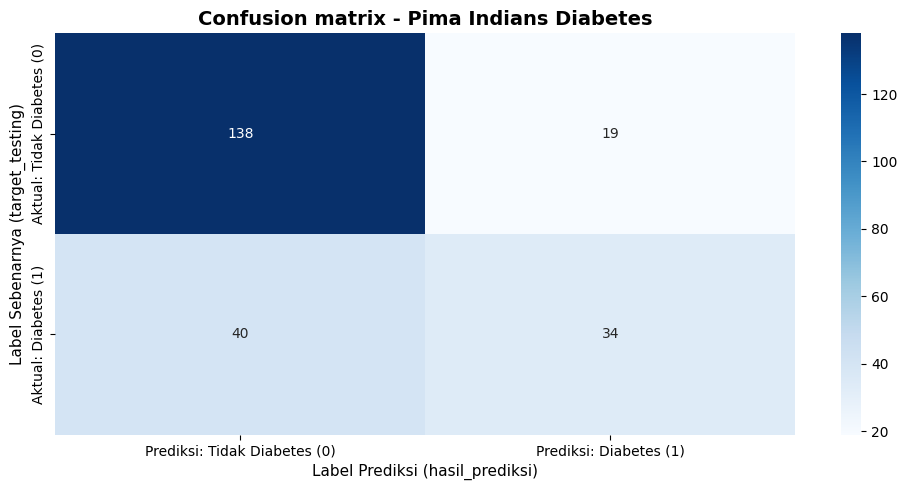

In [ ]:
# Visualisasi Confusion matrix
plt.figure(figsize=(10, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Prediksi: Tidak Diabetes (0)', 'Prediksi: Diabetes (1)'],
    yticklabels=['Aktual: Tidak Diabetes (0)', 'Aktual: Diabetes (1)']
)
plt.title('Confusion matrix - Pima Indians Diabetes', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya (target_testing)', fontsize=11)
plt.xlabel('Label Prediksi (hasil_prediksi)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Tampilan laporan klasifikasi
laporan = classification_report(target_testing, hasil_prediksi, target_names=['Tidak Diabetes (0)', 'Diabetes (1)'])
print("Laporan Klasifikasi:")
print(laporan)

Laporan Klasifikasi:
                    precision    recall  f1-score   support

Tidak Diabetes (0)       0.78      0.88      0.82       157
      Diabetes (1)       0.64      0.46      0.54        74

          accuracy                           0.74       231
         macro avg       0.71      0.67      0.68       231
      weighted avg       0.73      0.74      0.73       231



#7. Hasil prediksi dengan label sebenarnya

In [ ]:
# Tampilan 15 contoh prediksi beserta probabilitasnya
tabel_hasil = pd.DataFrame({
    'Label Sebenarnya (target_testing)'    : target_testing.values[:15],
    'Hasil Prediksi (hasil_prediksi)'  : hasil_prediksi[:15],
    'P(Tidak Diabetes)'                : probabilitas_prediksi[:15, 0].round(3),
    'P(Diabetes)'                      : probabilitas_prediksi[:15, 1].round(3),
})
tabel_hasil['Status'] = tabel_hasil.apply(
    lambda baris: 'Benar' if baris['Label Sebenarnya (target_testing)'] == baris['Hasil Prediksi (hasil_prediksi)'] else 'Salah',
    axis=1
)
tabel_hasil.index = range(1, 16)
print(tabel_hasil.to_string())

    Label Sebenarnya (target_testing)  Hasil Prediksi (hasil_prediksi)  P(Tidak Diabetes)  P(Diabetes) Status
1                                   1                                1              0.097        0.903  Benar
2                                   0                                0              0.812        0.188  Benar
3                                   0                                0              0.855        0.145  Benar
4                                   1                                1              0.317        0.683  Benar
5                                   0                                0              0.834        0.166  Benar
6                                   0                                0              0.935        0.065  Benar
7                                   1                                1              0.321        0.679  Benar
8                                   1                                1              0.239        0.761  Benar
9         

#8. Analisis

Berdasarkan hasil yang telah diperoleh dari model Logistic Regression:

**Performa Model:**
*   **Akurasi Model:** Model ini memiliki akurasi sebesar 0.74, yang berarti model berhasil memprediksi dengan benar sekitar 74% dari keseluruhan data uji.

**Analisis Confusion Matrix:**
*   **True Negative (TN): 138** - Model dengan benar memprediksi 138 orang tidak menderita diabetes.
*   **False Positive (FP): 19** - Model secara salah memprediksi 19 orang menderita diabetes (padahal sebenarnya tidak). Ini dikenal sebagai kesalahan Tipe I.
*   **False Negative (FN): 40** - Model secara salah memprediksi 40 orang tidak menderita diabetes (padahal sebenarnya menderita). Ini dikenal sebagai kesalahan Tipe II, dan dalam konteks medis, ini bisa menjadi lebih kritis karena diagnosis yang terlewat.
*   **True Positive (TP): 34** - Model dengan benar memprediksi 34 orang menderita diabetes.

**Analisis Laporan Klasifikasi:**
*   **Kelas 'Tidak Diabetes (0)':**
    *   **Precision (0.78):** Dari semua yang diprediksi tidak diabetes, 78% di antaranya benar-benar tidak diabetes.
    *   **Recall (0.88):** Model berhasil mengidentifikasi 88% dari semua orang yang sebenarnya tidak diabetes.
    *   **F1-Score (0.82):** Merupakan rata-rata harmonik dari precision dan recall, menunjukkan keseimbangan yang baik untuk kelas ini.
*   **Kelas 'Diabetes (1)':**
    *   **Precision (0.64):** Dari semua yang diprediksi diabetes, 64% di antaranya benar-benar diabetes.
    *   **Recall (0.46):** Model hanya berhasil mengidentifikasi 46% dari semua orang yang sebenarnya menderita diabetes. Nilai recall yang rendah ini menunjukkan bahwa model masih banyak melewatkan kasus positif (False Negative yang tinggi).
    *   **F1-Score (0.54):** Lebih rendah dibandingkan kelas 'Tidak Diabetes', menunjukkan ada ruang untuk peningkatan dalam mendeteksi kasus diabetes.

**Analisis Rasio Odds (Odds Ratio):**
*   **d_pedigree_function (1.5878):** Ini adalah fitur dengan rasio odds tertinggi. Setiap peningkatan satu unit dalam fungsi silsilah diabetes meningkatkan kemungkinan seseorang menderita diabetes sebesar 58.78% (dengan asumsi fitur lain konstan). Ini menunjukkan bahwa riwayat keluarga yang kuat terhadap diabetes adalah prediktor yang paling signifikan.
*   **times_pregnant (1.0923):** Setiap penambahan satu kehamilan meningkatkan kemungkinan diabetes sebesar 9.23%.
*   **bmi (1.0777):** Setiap peningkatan satu unit pada BMI meningkatkan kemungkinan diabetes sebesar 7.77%.
*   **glucose_concentration (1.0319):** Peningkatan konsentrasi glukosa juga sedikit meningkatkan kemungkinan diabetes.
*   Fitur lain seperti `diastolic_blood_pressure`, `triceps_sf_thickness`, dan `serum_insulin` memiliki rasio odds mendekati 1 atau di bawah 1, menunjukkan pengaruh yang lebih kecil atau bahkan sedikit mengurangi kemungkinan diabetes (untuk tekanan darah diastolik).

#9. Kesimpulan

Secara keseluruhan, model Regresi Logistik yang dibangun untuk memprediksi diabetes menunjukkan performa yang cukup baik dengan akurasi 74%. Namun, terdapat perbedaan performa yang signifikan antara prediksi untuk kelas 'Tidak Diabetes' dan 'Diabetes'.

Model sangat baik dalam mengidentifikasi individu yang **tidak menderita diabetes (Kelas 0)**, dibuktikan dengan recall sebesar 88%. Artinya, sebagian besar orang yang tidak diabetes berhasil diidentifikasi dengan benar.

Sebaliknya, model **kurang optimal dalam mendeteksi individu yang menderita diabetes (Kelas 1)**, dengan recall hanya 46%. Ini mengindikasikan bahwa banyak kasus diabetes terlewatkan (False Negative tinggi), yang mana dalam konteks medis sangat penting untuk dihindari. Precision untuk kelas diabetes juga relatif rendah (64%), menandakan bahwa sekitar sepertiga dari prediksi positif diabetes ternyata salah.

Analisis Rasio Odds menyoroti **`d_pedigree_function` (riwayat keluarga)** sebagai prediktor paling kuat untuk diabetes, diikuti oleh `times_pregnant` dan `bmi`. Fitur-fitur ini menunjukkan peningkatan risiko diabetes yang signifikan.

**Kesimpulan:**
Model ini dapat memberikan indikasi awal dengan akurasi yang moderat, terutama dalam mengidentifikasi individu yang tidak berisiko. Namun, untuk aplikasi klinis, model memerlukan peningkatan signifikan dalam kemampuannya mendeteksi kasus diabetes (recall untuk Kelas 1) guna mengurangi jumlah *False Negative* yang berpotensi berbahaya. Perbaikan lebih lanjut dapat melibatkan penyesuaian *threshold* klasifikasi, penggunaan teknik *resampling* untuk menangani ketidakseimbangan kelas, atau eksplorasi model klasifikasi lain yang lebih kompleks.